# LSTM Carbon Intensity Forecasting — v4 (no data leakage)

**Key insight from v2/v3:** Features like `wind_power_mw`, `renewable_share`, and `solar_power_mw` 
are measured at the same time as carbon intensity. The model learns to exploit contemporaneous 
correlations that don't exist at inference time (when predicting 1-24 hours ahead). This causes 
overfitting — training loss drops but validation loss rises.

**v4 approach — only use features genuinely available at forecast time:**
- Carbon intensity history (autoregressive — always available from past)
- diff_1, diff_24 (derived from past carbon intensity)
- Hour of day, season, day of week (always known)
- Wind speed, temperature (weather changes slowly — recent past is predictive)
- Day-ahead electricity price (published the evening before — known 12-36h ahead)

**Removed:** wind_power_mw, solar_power_mw, renewable_share, solar_radiation

**Model:** Back to 64 units (10 features don't need 128), 57K params — same size as v1.

| Version | Features | Params | MAE | MAPE | Issue |
|---------|----------|--------|-----|------|-------|
| v1 | 7 (univariate) | 57K | 20.85 | 34.5% | Baseline |
| v2 | 16 (all data) | 225K | 19.51 | 31.1% | Truncated test set |
| v3 | 15 (all data) | 225K | 21.38 | 34.3% | Overfitting / data leakage |
| v4 | 10 (no leakage) | 57K | ? | ? | This notebook |


# Imports & Configuration

In [1]:
import os
import glob
import json
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")


TensorFlow: 2.20.0
GPU available: False


In [2]:
# ─── Paths ───
EMISSIONS_PATH   = "../emissions-data"
WEATHER_PATH     = "../weather"
PRICES_PATH      = "../prices"

TARGET_COL = "Carbon intensity gCO₂eq/kWh (direct)"

# ─── Model hyperparameters ───
WINDOW_SIZE        = 168          # 7 days of hourly history
FORECAST_HORIZON   = 24           # predict next 24 hours
HIDDEN_SIZE        = 64           # back to v1 size — 10 features don't need 128
NUM_LAYERS         = 2
DROPOUT            = 0.2          # reduced from 0.3 — smaller model needs less regularization
LEARNING_RATE      = 0.001        # back to v1 rate — smaller model converges fine with this
EPOCHS             = 50
BATCH_SIZE         = 64

LOG_DIR    = "logs_lstm_v4"
MODEL_DIR  = "saved_model_lstm_v4"
TFLITE_PATH = "carbon_model_lstm_v4.tflite"

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)


# Load Carbon Intensity Data

In [3]:
csv_files = sorted(glob.glob(os.path.join(EMISSIONS_PATH, "*.csv")))
df = pd.concat(
    (pd.read_csv(f, parse_dates=["Datetime (UTC)"]) for f in csv_files),
    ignore_index=True
)
df = df.sort_values("Datetime (UTC)").reset_index(drop=True)
df = df[["Datetime (UTC)", TARGET_COL]].copy()

print(f"Emissions data: {len(df)} rows")
print(f"Date range: {df['Datetime (UTC)'].min()} to {df['Datetime (UTC)'].max()}")


Emissions data: 43824 rows
Date range: 2021-01-01 00:00:00 to 2025-12-31 23:00:00


# Load Weather Data (DMI)

Only wind speed and temperature — these change slowly enough that recent-past values 
are predictive of the next 24 hours. Solar radiation is dropped because it has strong
contemporaneous correlation with carbon intensity (sunny = solar panels active = low carbon)
but yesterday's sunshine doesn't predict tomorrow's.


In [4]:
def load_dmi_data(pattern, value_col, new_name):
    """Load DMI weather CSVs, aggregate across stations to hourly Denmark-wide values."""
    files = sorted(glob.glob(os.path.join(WEATHER_PATH, pattern)))
    if not files:
        print(f"  ⚠️  No files found for pattern: {pattern}")
        return pd.DataFrame()
    
    dfs = []
    for f in files:
        try:
            d = pd.read_csv(f)
            dfs.append(d)
        except Exception as e:
            print(f"  ⚠️  Could not read {f}: {e}")

    if not dfs:
        return pd.DataFrame()

    weather = pd.concat(dfs, ignore_index=True)

    # Parse datetime — handles timezone-aware strings with milliseconds
    weather["timeObserved"] = pd.to_datetime(weather["timeObserved"], format="ISO8601", utc=True)
    weather["timeObserved"] = weather["timeObserved"].dt.tz_localize(None)

    # Floor to hour
    weather["hour_utc"] = weather["timeObserved"].dt.floor("h")

    # Aggregate: median across all stations per hour
    hourly = weather.groupby("hour_utc")[value_col].median().reset_index()
    hourly.columns = ["Datetime (UTC)", new_name]
    
    print(f"  {new_name}: {len(hourly)} hours from {len(files)} files, "
          f"{weather['stationId'].nunique()} stations")
    
    return hourly

print("Loading DMI weather data...")
wind_df = load_dmi_data("*_dmi_wind*", "mean_wind_speed", "wind_speed")
temp_df = load_dmi_data("*_dmi_temp*", "mean_temp", "temperature")


Loading DMI weather data...
  wind_speed: 52609 hours from 6 files, 57 stations
  temperature: 52609 hours from 6 files, 61 stations


# Load Day-Ahead Electricity Prices

Day-ahead prices are published the evening before, so they're genuinely known 12-36 hours 
in advance. This is one of the few exogenous features with NO data leakage — the price for 
tomorrow's hours is set today.


In [5]:
# ─── Old format (2021-2024, hourly, DK1 only) ───
old_price_files = sorted(glob.glob(os.path.join(PRICES_PATH, "DayAheadPrices_DK1_*.csv")))
print(f"Old format price files: {len(old_price_files)}")

old_price_dfs = []
for f in old_price_files:
    try:
        d = pd.read_csv(f)
        old_price_dfs.append(d)
    except Exception as e:
        print(f"  ⚠️  Could not read {f}: {e}")

if old_price_dfs:
    old_prices = pd.concat(old_price_dfs, ignore_index=True)
    old_prices["Datetime (UTC)"] = pd.to_datetime(
        old_prices["MTU (UTC)"].str.split(" - ").str[0],
        format="%d/%m/%Y %H:%M:%S"
    )
    old_prices["price_eur_mwh"] = pd.to_numeric(old_prices["Day-ahead Price (EUR/MWh)"], errors="coerce")
    old_prices = old_prices[["Datetime (UTC)", "price_eur_mwh"]].dropna()
    print(f"  Old prices: {len(old_prices)} rows, {old_prices['Datetime (UTC)'].min()} to {old_prices['Datetime (UTC)'].max()}")
else:
    old_prices = pd.DataFrame(columns=["Datetime (UTC)", "price_eur_mwh"])

# ─── New format (2025, 15-minute, separate DK1 + DK2) ───
new_price_files = sorted(glob.glob(os.path.join(PRICES_PATH, "DK*-DayAhead_Prices-*.csv")))
print(f"New format price files: {len(new_price_files)}")

new_price_dfs = []
for f in new_price_files:
    try:
        d = pd.read_csv(f)
        new_price_dfs.append(d)
    except Exception as e:
        print(f"  ⚠️  Could not read {f}: {e}")

if new_price_dfs:
    new_prices = pd.concat(new_price_dfs, ignore_index=True)
    new_prices["Datetime (UTC)"] = pd.to_datetime(
        new_prices["MTU (UTC)"].str.split(" - ").str[0],
        format="%d/%m/%Y %H:%M:%S"
    )
    new_prices["price_eur_mwh"] = pd.to_numeric(new_prices["Day-ahead Price (EUR/MWh)"], errors="coerce")
    new_prices = new_prices[["Datetime (UTC)", "price_eur_mwh"]].dropna()
    
    # 15-min → hourly, average across DK1+DK2
    new_prices = new_prices.set_index("Datetime (UTC)")
    new_prices = new_prices.resample("1h").mean().reset_index()
    print(f"  New prices (resampled): {len(new_prices)} rows, "
          f"{new_prices['Datetime (UTC)'].min()} to {new_prices['Datetime (UTC)'].max()}")
else:
    new_prices = pd.DataFrame(columns=["Datetime (UTC)", "price_eur_mwh"])

# ─── Combine ───
prices = pd.concat([old_prices, new_prices], ignore_index=True)
prices = prices.drop_duplicates(subset="Datetime (UTC)").sort_values("Datetime (UTC)")
prices = prices.reset_index(drop=True)

print(f"\nCombined prices: {len(prices)} rows")
print(f"Date range: {prices['Datetime (UTC)'].min()} to {prices['Datetime (UTC)'].max()}")


Old format price files: 5
  Old prices: 41303 rows, 2020-12-31 23:00:00 to 2025-09-17 21:00:00
New format price files: 2
  New prices (resampled): 8760 rows, 2025-01-01 00:00:00 to 2025-12-31 23:00:00

Combined prices: 43825 rows
Date range: 2020-12-31 23:00:00 to 2025-12-31 23:00:00


# Merge All Datasets

Note: NO electricity production data in v4 — those features (wind_power_mw, renewable_share) 
had data leakage (contemporaneous with target).


In [6]:
merged = df.copy()

# Merge weather (only wind + temperature)
for weather_df in [wind_df, temp_df]:
    if len(weather_df) > 0:
        merged = merged.merge(weather_df, on="Datetime (UTC)", how="left")

# Merge prices
merged = merged.merge(prices, on="Datetime (UTC)", how="left")

# ─── Time features ───
merged["hour"] = merged["Datetime (UTC)"].dt.hour
merged["day_of_year"] = merged["Datetime (UTC)"].dt.dayofyear
merged["day_of_week"] = merged["Datetime (UTC)"].dt.dayofweek

# Cyclical encodings
merged["hour_sin"]  = np.sin(2 * np.pi * merged["hour"] / 24)
merged["hour_cos"]  = np.cos(2 * np.pi * merged["hour"] / 24)
merged["year_sin"]  = np.sin(2 * np.pi * merged["day_of_year"] / 365.25)
merged["year_cos"]  = np.cos(2 * np.pi * merged["day_of_year"] / 365.25)
merged["dow_sin"]   = np.sin(2 * np.pi * merged["day_of_week"] / 7)
merged["dow_cos"]   = np.cos(2 * np.pi * merged["day_of_week"] / 7)

# ─── Differencing ───
merged["diff_1"]  = merged[TARGET_COL].diff(1)
merged["diff_24"] = merged[TARGET_COL].diff(24)

# Drop NaN rows
merged = merged.dropna().reset_index(drop=True)

print(f"Merged dataset: {len(merged)} rows")
print(f"Date range: {merged['Datetime (UTC)'].min()} to {merged['Datetime (UTC)'].max()}")
print(f"\nColumns ({len(merged.columns)}):")
for col in merged.columns:
    if merged[col].dtype in ['float64', 'int64']:
        print(f"  {col:45s}  range: [{merged[col].min():.2f}, {merged[col].max():.2f}]")
    else:
        print(f"  {col}")


Merged dataset: 43800 rows
Date range: 2021-01-02 00:00:00 to 2025-12-31 23:00:00

Columns (16):
  Datetime (UTC)
  Carbon intensity gCO₂eq/kWh (direct)           range: [12.55, 456.96]
  wind_speed                                     range: [0.60, 16.90]
  temperature                                    range: [-10.55, 30.00]
  price_eur_mwh                                  range: [-440.10, 936.28]
  hour
  day_of_year
  day_of_week
  hour_sin                                       range: [-1.00, 1.00]
  hour_cos                                       range: [-1.00, 1.00]
  year_sin                                       range: [-1.00, 1.00]
  year_cos                                       range: [-1.00, 1.00]
  dow_sin                                        range: [-0.97, 0.97]
  dow_cos                                        range: [-0.90, 1.00]
  diff_1                                         range: [-104.63, 130.48]
  diff_24                                        range: [-277.28, 279

# Feature Selection

**10 features — all genuinely available at forecast time:**
- Carbon intensity + diffs: autoregressive (from the 168h input window)
- Hour, season, day-of-week: always known for any future time
- Wind speed, temperature: slowly changing — last 168h is predictive
- Price: day-ahead prices are published ~12-36h before delivery


In [7]:
FEATURES = [
    # ─── Autoregressive ───
    TARGET_COL,            # past carbon intensity values
    "diff_1",              # 1-hour change  
    "diff_24",             # 24-hour change
    
    # ─── Time (always known) ───
    "hour_sin", "hour_cos",
    "year_sin", "year_cos",
    "dow_sin", "dow_cos",
    
    # ─── Exogenous (legitimately available) ───
    "wind_speed",          # DMI — weather changes slowly, recent past is predictive
    "temperature",         # DMI — same reasoning
    "price_eur_mwh",       # day-ahead prices are known 12-36h in advance
]

print(f"Total features: {len(FEATURES)}")
for i, f in enumerate(FEATURES):
    print(f"  [{i:2d}] {f}")


Total features: 12
  [ 0] Carbon intensity gCO₂eq/kWh (direct)
  [ 1] diff_1
  [ 2] diff_24
  [ 3] hour_sin
  [ 4] hour_cos
  [ 5] year_sin
  [ 6] year_cos
  [ 7] dow_sin
  [ 8] dow_cos
  [ 9] wind_speed
  [10] temperature
  [11] price_eur_mwh


# Split Data

In [8]:
train = merged[(merged["Datetime (UTC)"].dt.year >= 2021) &
               (merged["Datetime (UTC)"].dt.year <= 2023)]
val = merged[merged["Datetime (UTC)"].dt.year == 2024]
test = merged[merged["Datetime (UTC)"].dt.year == 2025]

print(f"Train: {len(train)} rows ({train['Datetime (UTC)'].min().date()} to {train['Datetime (UTC)'].max().date()})")
print(f"Val:   {len(val)} rows ({val['Datetime (UTC)'].min().date()} to {val['Datetime (UTC)'].max().date()})")
print(f"Test:  {len(test)} rows ({test['Datetime (UTC)'].min().date()} to {test['Datetime (UTC)'].max().date()})")


Train: 26256 rows (2021-01-02 to 2023-12-31)
Val:   8784 rows (2024-01-01 to 2024-12-31)
Test:  8760 rows (2025-01-01 to 2025-12-31)


# Normalization

In [9]:
feature_scaler = StandardScaler()

train = train.copy()
val = val.copy()
test = test.copy()

train[FEATURES] = feature_scaler.fit_transform(train[FEATURES])
val[FEATURES]   = feature_scaler.transform(val[FEATURES])
test[FEATURES]  = feature_scaler.transform(test[FEATURES])

# Extract target-only scaler for inverse_transform
target_idx = FEATURES.index(TARGET_COL)
target_scaler = StandardScaler()
target_scaler.mean_ = np.array([feature_scaler.mean_[target_idx]])
target_scaler.scale_ = np.array([feature_scaler.scale_[target_idx]])
target_scaler.var_ = np.array([feature_scaler.var_[target_idx]])
target_scaler.n_features_in_ = 1
target_scaler.n_samples_seen_ = feature_scaler.n_samples_seen_

# Save scaler parameters for Android
scaler_params = {
    "target_mean": target_scaler.mean_.tolist(),
    "target_scale": target_scaler.scale_.tolist(),
    "feature_names": FEATURES,
    "feature_means": feature_scaler.mean_.tolist(),
    "feature_scales": feature_scaler.scale_.tolist(),
}
with open("scaler_params_v4.json", "w") as f:
    json.dump(scaler_params, f, indent=4)

print(f"Target scaler — mean: {target_scaler.mean_[0]:.2f}, scale: {target_scaler.scale_[0]:.2f}")
print(f"\nAll feature means/scales:")
for i, feat in enumerate(FEATURES):
    print(f"  {feat:40s}: mean={feature_scaler.mean_[i]:8.2f}, scale={feature_scaler.scale_[i]:8.2f}")


Target scaler — mean: 119.08, scale: 63.90

All feature means/scales:
  Carbon intensity gCO₂eq/kWh (direct)    : mean=  119.08, scale=   63.90
  diff_1                                  : mean=   -0.00, scale=   15.17
  diff_24                                 : mean=   -0.04, scale=   48.93
  hour_sin                                : mean=   -0.00, scale=    0.71
  hour_cos                                : mean=   -0.00, scale=    0.71
  year_sin                                : mean=   -0.00, scale=    0.71
  year_cos                                : mean=   -0.00, scale=    0.71
  dow_sin                                 : mean=   -0.00, scale=    0.71
  dow_cos                                 : mean=    0.00, scale=    0.71
  wind_speed                              : mean=    4.50, scale=    2.21
  temperature                             : mean=    9.48, scale=    6.48
  price_eur_mwh                           : mean=  131.41, scale=  114.44


# Create Windowed Dataset

In [10]:
def create_dataset(data):
    x, y = [], []
    values = data[FEATURES].values
    target = data[TARGET_COL].values

    for i in range(WINDOW_SIZE, len(data) - FORECAST_HORIZON):
        x.append(values[i-WINDOW_SIZE:i])
        y.append(target[i:i+FORECAST_HORIZON])

    return np.array(x), np.array(y)

x_train, y_train = create_dataset(train)
x_val, y_val = create_dataset(val)
x_test, y_test = create_dataset(test)

print(f"x_train: {x_train.shape} | y_train: {y_train.shape}")
print(f"x_val:   {x_val.shape}  | y_val:   {y_val.shape}")
print(f"x_test:  {x_test.shape}  | y_test:  {y_test.shape}")

# Sanity check
print(f"\nFeature stats in x_train (should all be ~mean 0, std 1):")
for i, f in enumerate(FEATURES):
    vals = x_train[:, :, i].flatten()
    print(f"  {f:40s}: mean={vals.mean():.3f}, std={vals.std():.3f}")


x_train: (26064, 168, 12) | y_train: (26064, 24)
x_val:   (8592, 168, 12)  | y_val:   (8592, 24)
x_test:  (8568, 168, 12)  | y_test:  (8568, 24)

Feature stats in x_train (should all be ~mean 0, std 1):
  Carbon intensity gCO₂eq/kWh (direct)    : mean=0.000, std=1.002
  diff_1                                  : mean=-0.000, std=1.002
  diff_24                                 : mean=-0.000, std=1.002
  hour_sin                                : mean=-0.000, std=1.000
  hour_cos                                : mean=0.000, std=1.000
  year_sin                                : mean=-0.000, std=1.004
  year_cos                                : mean=-0.010, std=0.996
  dow_sin                                 : mean=0.002, std=0.999
  dow_cos                                 : mean=-0.001, std=1.001
  wind_speed                              : mean=-0.003, std=0.999
  temperature                             : mean=0.007, std=1.000
  price_eur_mwh                           : mean=0.006, std=1.00

# Build LSTM Model (v4)

Same architecture as v1 but with 12 input features instead of 7.
64 units, 2 layers, ~60K parameters. Small and fast.


In [11]:
num_features = len(FEATURES)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW_SIZE, num_features)),

    # LSTM layer 1
    tf.keras.layers.LSTM(
        HIDDEN_SIZE,
        return_sequences=True,
        unroll=True,
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    ),
    tf.keras.layers.Dropout(DROPOUT),

    # LSTM layer 2
    tf.keras.layers.LSTM(
        HIDDEN_SIZE,
        return_sequences=False,
        unroll=True,
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    ),
    tf.keras.layers.Dropout(DROPOUT),

    # Dense head
    tf.keras.layers.Dense(HIDDEN_SIZE, activation="relu"),
    tf.keras.layers.Dropout(DROPOUT),
    tf.keras.layers.Dense(FORECAST_HORIZON)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse",
    metrics=["mae"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 64)        │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,456 (228.34 KB)

 Trainable params: 58,456 (228.34 KB)

 Non-trainable params: 0 (0.00 B)

# Callbacks

In [12]:
tensorboard_cb = tf.keras.callbacks.TensorBoard(log_dir=LOG_DIR)

csv_logger = tf.keras.callbacks.CSVLogger("training_log_lstm_v4.csv")

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(MODEL_DIR, "best_model.keras"),
    monitor="val_loss",
    save_best_only=True
)


# Train

In [13]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[tensorboard_cb, csv_logger, early_stop, reduce_lr, checkpoint]
)


Epoch 1/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 123s 151ms/step - loss: 0.4320 - mae: 0.4778 - val_loss: 0.2640 - val_mae: 0.3784 - learning_rate: 0.0010
Epoch 2/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 46s 112ms/step - loss: 0.3275 - mae: 0.4217 - val_loss: 0.2819 - val_mae: 0.3986 - learning_rate: 0.0010
Epoch 3/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 49s 121ms/step - loss: 0.2781 - mae: 0.3930 - val_loss: 0.2780 - val_mae: 0.3878 - learning_rate: 0.0010
Epoch 4/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 49s 121ms/step - loss: 0.2391 - mae: 0.3656 - val_loss: 0.2990 - val_mae: 0.3969 - learning_rate: 0.0010
Epoch 5/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 49s 119ms/step - loss: 0.2004 - mae: 0.3353 - val_loss: 0.3089 - val_mae: 0.4009 - learning_rate: 5.0000e-04
Epoch 6/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 46s 114ms/step - loss: 0.1860 - mae: 0.3228 - val_loss: 0.3344 - val_mae: 0.4151 - learning_rate: 5.0000e-04


# Training Curves

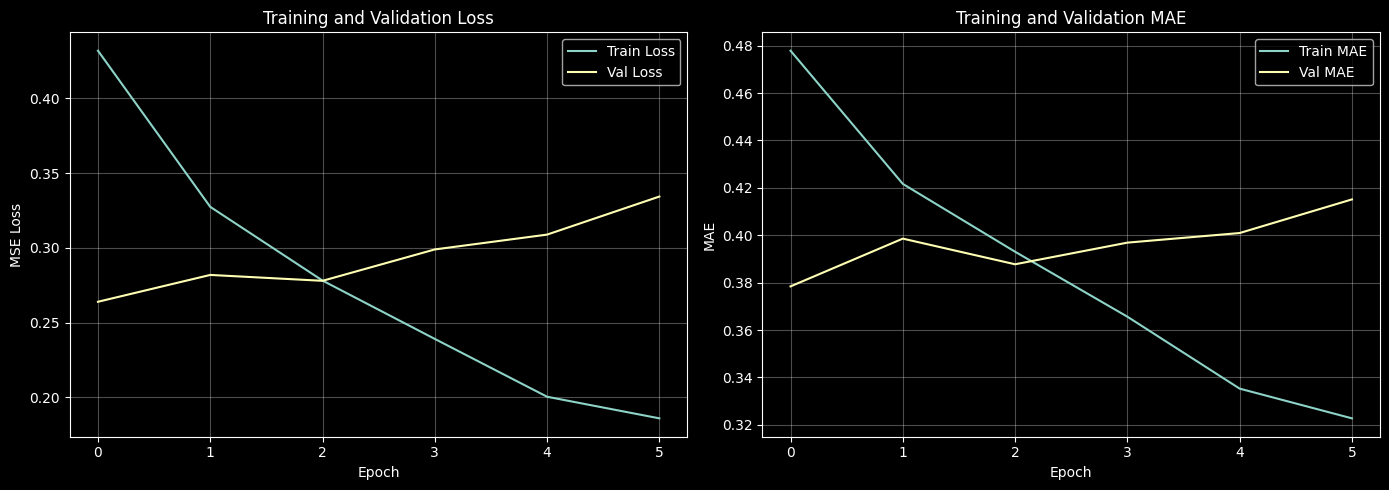

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history["loss"], label="Train Loss")
ax1.plot(history.history["val_loss"], label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE Loss")
ax1.set_title("Training and Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history["mae"], label="Train MAE")
ax2.plot(history.history["val_mae"], label="Val MAE")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("MAE")
ax2.set_title("Training and Validation MAE")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Evaluate

In [15]:
test_loss, test_mae = model.evaluate(x_test, y_test)
print(f"Test MSE (scaled): {test_loss:.6f}")
print(f"Test MAE (scaled): {test_mae:.6f}")

pred_all_scaled = model.predict(x_test)

pred_all = target_scaler.inverse_transform(
    pred_all_scaled.reshape(-1, 1)
).reshape(-1, FORECAST_HORIZON)

true_all = target_scaler.inverse_transform(
    y_test.reshape(-1, 1)
).reshape(-1, FORECAST_HORIZON)

overall_mae = np.mean(np.abs(pred_all - true_all))
overall_rmse = np.sqrt(np.mean((pred_all - true_all) ** 2))

mask = np.abs(true_all) > 1.0
overall_mape = np.mean(np.abs((true_all[mask] - pred_all[mask]) / true_all[mask])) * 100

print(f"\nTest Results (original units):")
print(f"  Overall MAE:  {overall_mae:.2f} gCO₂eq/kWh")
print(f"  Overall RMSE: {overall_rmse:.2f} gCO₂eq/kWh")
print(f"  Overall MAPE: {overall_mape:.1f}%")

print(f"\n{'='*65}")
print(f"  Version comparison (full 2025 test set):")
print(f"  {'':15s} {'MAE':>8s} {'MAPE':>8s} {'RMSE':>8s} {'Params':>8s}")
print(f"  {'-'*50}")
print(f"  {'v1 (univariate)':15s} {'20.85':>8s} {'34.5%':>8s} {'28.07':>8s} {'57K':>8s}")
print(f"  {'v3 (leakage)':15s} {'21.38':>8s} {'34.3%':>8s} {'28.32':>8s} {'225K':>8s}")
print(f"  {'v4 (clean)':15s} {overall_mae:>8.2f} {overall_mape:>7.1f}% {overall_rmse:>8.2f} {'~60K':>8s}")
v1_imp = (20.85 - overall_mae) / 20.85 * 100
print(f"  Improvement over v1: {v1_imp:+.1f}%")
print(f"{'='*65}")


268/268 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.1992 - mae: 0.3268
Test MSE (scaled): 0.199186
Test MAE (scaled): 0.326795
268/268 ━━━━━━━━━━━━━━━━━━━━ 32s 74ms/step

Test Results (original units):
  Overall MAE:  20.88 gCO₂eq/kWh
  Overall RMSE: 27.84 gCO₂eq/kWh
  Overall MAPE: 34.1%

  Version comparison (full 2025 test set):
                       MAE     MAPE     RMSE   Params
  --------------------------------------------------
  v1 (univariate)    20.85    34.5%    28.07      57K
  v3 (leakage)       21.38    34.3%    28.32     225K
  v4 (clean)         20.88    34.1%    27.84     ~60K
  Improvement over v1: -0.1%


# Save Model

In [16]:
model.save(os.path.join(MODEL_DIR, "final_model.keras"))


# Convert to TFLite

In [17]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
]

tflite_model = converter.convert()

with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

size_kb = os.path.getsize(TFLITE_PATH) / 1024
print(f"TFLite model saved: {TFLITE_PATH} ({size_kb:.1f} KB)")


INFO:tensorflow:Assets written to: C:\Users\jbro9\AppData\Local\Temp\tmpkjo8yycu\assets


INFO:tensorflow:Assets written to: C:\Users\jbro9\AppData\Local\Temp\tmpkjo8yycu\assets


Saved artifact at 'C:\Users\jbro9\AppData\Local\Temp\tmpkjo8yycu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 168, 12), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 24), dtype=tf.float32, name=None)
Captures:
  2150270396624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2150270398160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2150270397392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2150270397200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2150270397968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2150270397776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2150270398928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2150270397008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2150270398544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2150270399504: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite mod

# Save Hyperparameters

In [18]:
params = {
    "model": "LSTM_v4",
    "window_size": WINDOW_SIZE,
    "forecast_horizon": FORECAST_HORIZON,
    "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS,
    "dropout": DROPOUT,
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "features": FEATURES,
    "num_features": len(FEATURES),
    "test_mae": float(overall_mae),
    "test_rmse": float(overall_rmse),
    "test_mape": float(overall_mape),
}

with open("model_params_lstm_v4.json", "w") as f:
    json.dump(params, f, indent=4)

print("Training complete.")


Training complete.


# One Random 24h Forecast

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


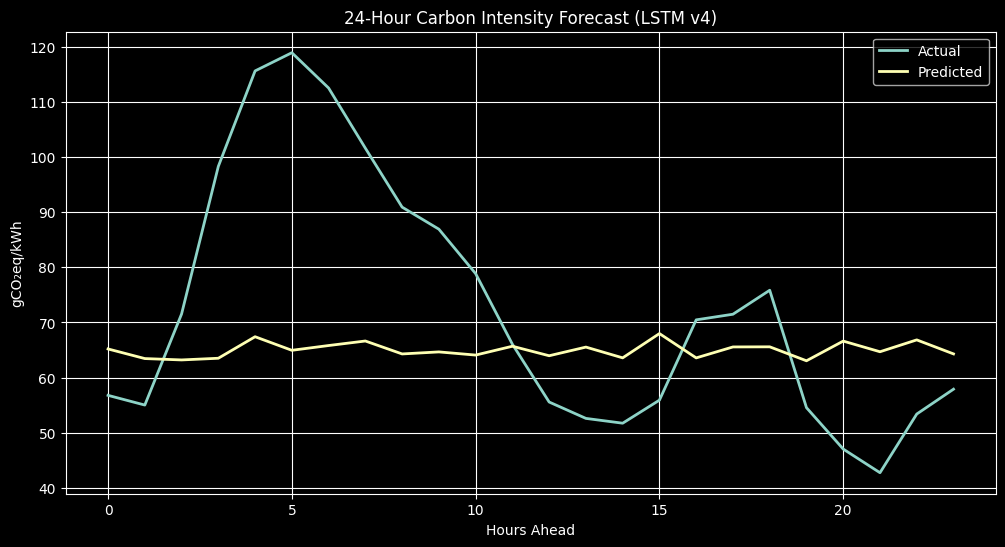

Sample MAE: 18.58 gCO₂eq/kWh


In [19]:
idx = np.random.randint(0, len(x_test))

input_sample = x_test[idx:idx+1]
true_future_scaled = y_test[idx]

pred_scaled = model.predict(input_sample)[0]

true_future = target_scaler.inverse_transform(
    true_future_scaled.reshape(-1, 1)
).flatten()

pred_future = target_scaler.inverse_transform(
    pred_scaled.reshape(-1, 1)
).flatten()

plt.figure(figsize=(12, 6))
hours = np.arange(FORECAST_HORIZON)

plt.plot(hours, true_future, label="Actual", linewidth=2)
plt.plot(hours, pred_future, label="Predicted", linewidth=2)

plt.title("24-Hour Carbon Intensity Forecast (LSTM v4)")
plt.xlabel("Hours Ahead")
plt.ylabel("gCO₂eq/kWh")
plt.legend()
plt.grid(True)
plt.show()

sample_mae = np.mean(np.abs(true_future - pred_future))
print(f"Sample MAE: {sample_mae:.2f} gCO₂eq/kWh")


# Best 3-Hour Charging Window

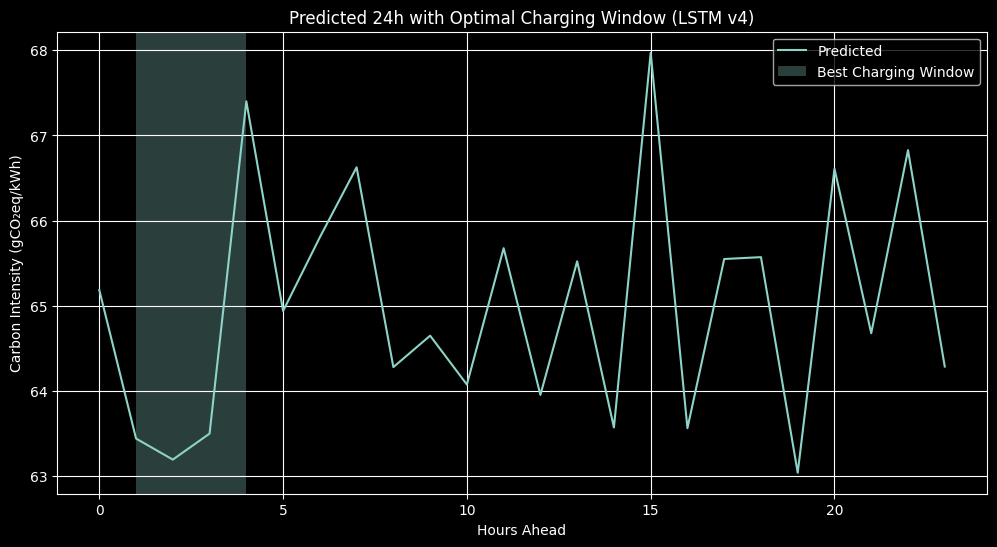

Best charging window: hour 1 to 4


In [20]:
window_size = 3

rolling_avg = np.convolve(
    pred_future,
    np.ones(window_size) / window_size,
    mode='valid'
)

best_start = np.argmin(rolling_avg)
best_end = best_start + window_size

plt.figure(figsize=(12, 6))
plt.plot(hours, pred_future, label="Predicted")

plt.axvspan(best_start, best_end,
            alpha=0.3,
            label="Best Charging Window")

plt.title("Predicted 24h with Optimal Charging Window (LSTM v4)")
plt.xlabel("Hours Ahead")
plt.ylabel("Carbon Intensity (gCO₂eq/kWh)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best charging window: hour {best_start} to {best_end}")


# Evaluate Error Per Forecast Hour

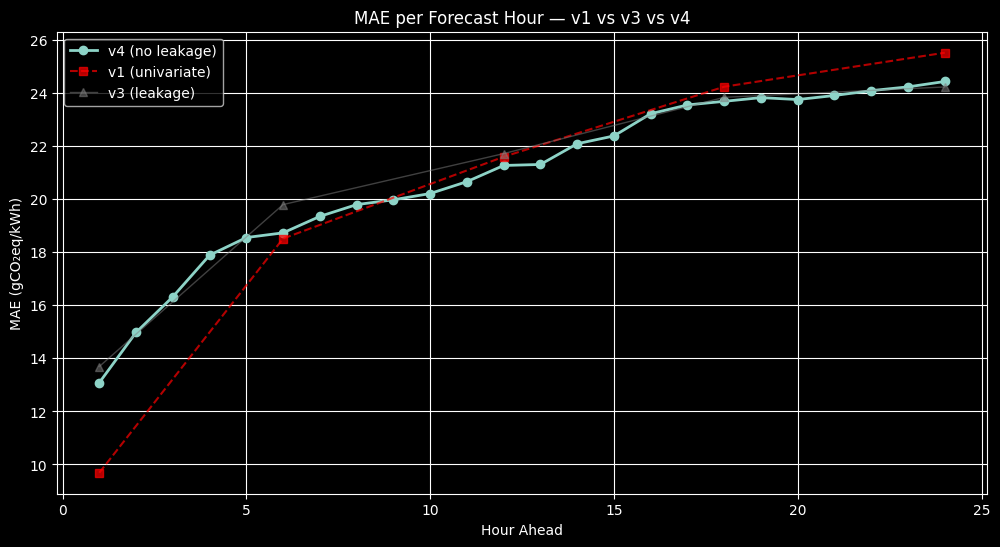

Per-hour MAE comparison:
  Hour        v4        v1        v3    v4 vs v1
----------------------------------------------
    1     13.08      9.69     13.69     -35.0%
    6     18.72     18.51     19.79      -1.2%
   12     21.26     21.59     21.71      +1.5%
   18     23.68     24.23     23.83      +2.3%
   24     24.43     25.51     24.22      +4.2%


In [21]:
mae_per_hour = np.mean(np.abs(pred_all - true_all), axis=0)

v1_hours = [1, 6, 12, 18, 24]
v1_values = [9.69, 18.51, 21.59, 24.23, 25.51]
v3_values = [13.69, 19.79, 21.71, 23.83, 24.22]

plt.figure(figsize=(12, 6))
plt.plot(range(1, FORECAST_HORIZON+1), mae_per_hour, marker='o', linewidth=2, label="v4 (no leakage)")
plt.plot(v1_hours, v1_values, 'r--', marker='s', linewidth=1.5, alpha=0.7, label="v1 (univariate)")
plt.plot(v1_hours, v3_values, 'gray', marker='^', linewidth=1, alpha=0.5, label="v3 (leakage)")

plt.title("MAE per Forecast Hour — v1 vs v3 vs v4")
plt.xlabel("Hour Ahead")
plt.ylabel("MAE (gCO₂eq/kWh)")
plt.legend()
plt.grid(True)
plt.show()

print("Per-hour MAE comparison:")
print(f"{'Hour':>6s}  {'v4':>8s}  {'v1':>8s}  {'v3':>8s}  {'v4 vs v1':>10s}")
print("-" * 46)
for h_idx, h in enumerate([0, 5, 11, 17, 23]):
    v1_val = v1_values[h_idx]
    v3_val = v3_values[h_idx]
    v4_val = mae_per_hour[h]
    change = (v1_val - v4_val) / v1_val * 100
    print(f"  {h+1:3d}   {v4_val:7.2f}   {v1_val:7.2f}   {v3_val:7.2f}   {change:+7.1f}%")


# Full 24h Forecast Distribution

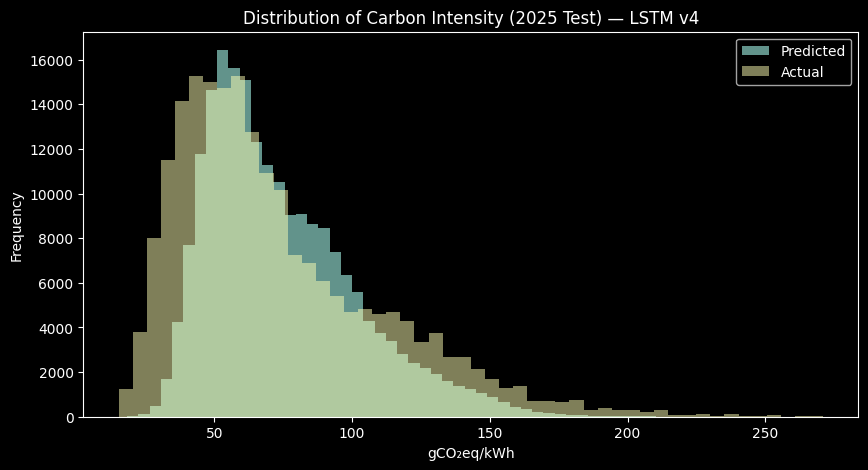

In [22]:
plt.figure(figsize=(10, 5))
plt.hist(pred_all.flatten(), bins=50, alpha=0.7, label="Predicted")
plt.hist(true_all.flatten(), bins=50, alpha=0.5, label="Actual")
plt.title("Distribution of Carbon Intensity (2025 Test) — LSTM v4")
plt.xlabel("gCO₂eq/kWh")
plt.ylabel("Frequency")
plt.legend()
plt.show()


# Seasonal Performance

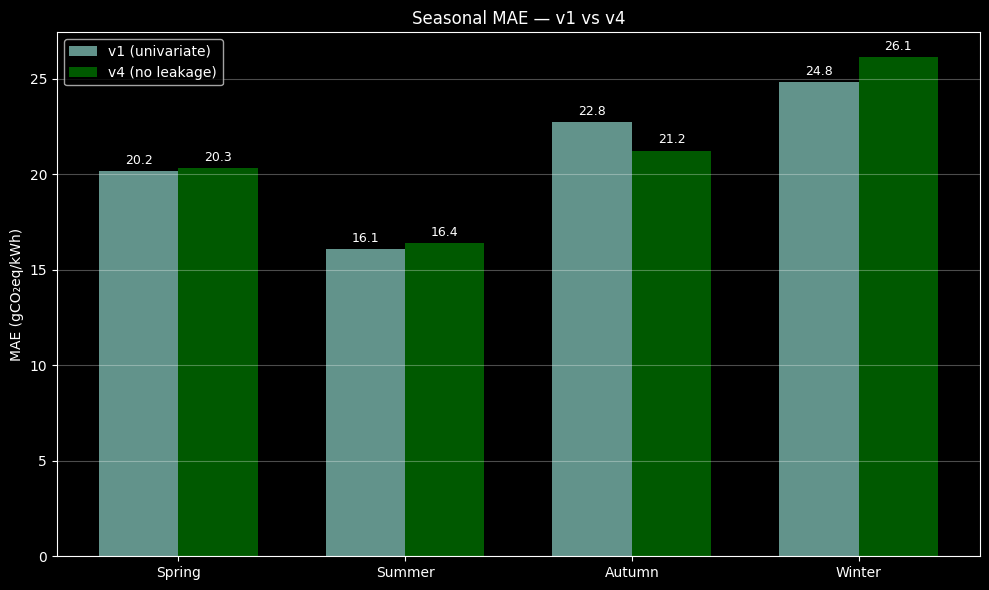

Seasonal MAE comparison:
  Spring  : v1=20.18  v4=20.32  (-0.7%)
  Summer  : v1=16.07  v4=16.40  (-2.1%)
  Autumn  : v1=22.75  v4=21.25  (+6.6%)
  Winter  : v1=24.84  v4=26.13  (-5.2%)


In [23]:
test_dates = test.iloc[WINDOW_SIZE:len(test)-FORECAST_HORIZON]["Datetime (UTC)"]

summer_mask = test_dates.dt.month.isin([6, 7, 8]).values
winter_mask = test_dates.dt.month.isin([12, 1, 2]).values
spring_mask = test_dates.dt.month.isin([3, 4, 5]).values
autumn_mask = test_dates.dt.month.isin([9, 10, 11]).values

summer_mae = np.mean(np.abs(pred_all[summer_mask] - true_all[summer_mask]))
winter_mae = np.mean(np.abs(pred_all[winter_mask] - true_all[winter_mask]))
spring_mae = np.mean(np.abs(pred_all[spring_mask] - true_all[spring_mask]))
autumn_mae = np.mean(np.abs(pred_all[autumn_mask] - true_all[autumn_mask]))

v1_seasonal = {"Spring": 20.18, "Summer": 16.07, "Autumn": 22.75, "Winter": 24.84}

seasons = ["Spring", "Summer", "Autumn", "Winter"]
v4_maes = [spring_mae, summer_mae, autumn_mae, winter_mae]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(seasons))
width = 0.35

bars1 = ax.bar(x - width/2, [v1_seasonal[s] for s in seasons], width, label="v1 (univariate)", alpha=0.7)
bars2 = ax.bar(x + width/2, v4_maes, width, label="v4 (no leakage)", alpha=0.7, color="green")

ax.set_ylabel("MAE (gCO₂eq/kWh)")
ax.set_title("Seasonal MAE — v1 vs v4")
ax.set_xticks(x)
ax.set_xticklabels(seasons)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

for bars in [bars1, bars2]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.1f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("Seasonal MAE comparison:")
for s, v4 in zip(seasons, v4_maes):
    v1 = v1_seasonal[s]
    change = (v1 - v4) / v1 * 100
    print(f"  {s:8s}: v1={v1:.2f}  v4={v4:.2f}  ({change:+.1f}%)")


# Scatter: Predicted vs Actual

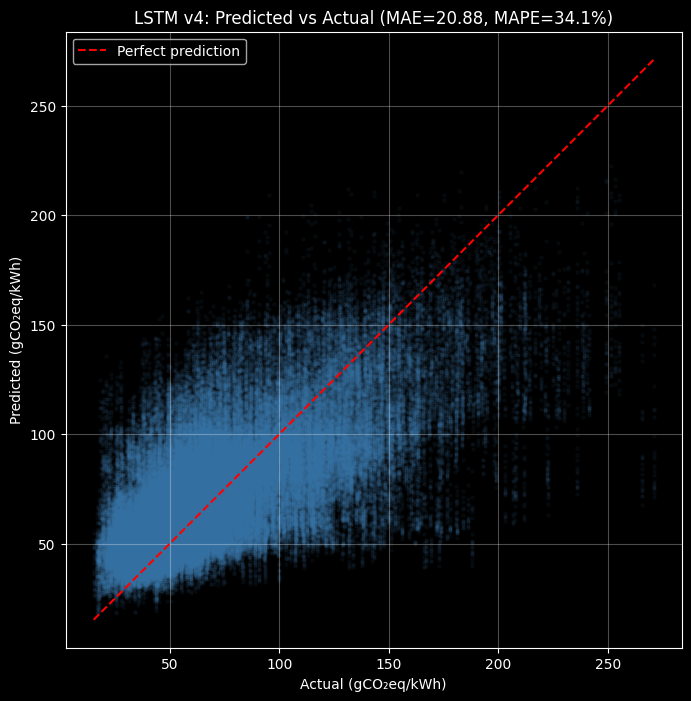

In [24]:
plt.figure(figsize=(8, 8))
pf = pred_all.flatten()
tf_ = true_all.flatten()
plt.scatter(tf_, pf, alpha=0.05, s=5, color="steelblue")
lims = [min(tf_.min(), pf.min()), max(tf_.max(), pf.max())]
plt.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual (gCO₂eq/kWh)")
plt.ylabel("Predicted (gCO₂eq/kWh)")
plt.title(f"LSTM v4: Predicted vs Actual (MAE={overall_mae:.2f}, MAPE={overall_mape:.1f}%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().set_aspect("equal")
plt.show()
